# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Kadek Gary Faldi
- Email: garyfaldi1@gmail.com
- Id Dicoding: garyfaldi - M297D5Y0931

## Persiapan

### Menyiapkan library yang dibutuhkan

In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded successfully!')

Libraries loaded successfully!


### Menyiapkan data yang akan digunakan

In [495]:
df = pd.read_csv('dataset/data.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [496]:
print('INFO DATASET')
df.info()
print()
print('STATISTIK DESKRIPTIF')
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [497]:
print('MISSING VALUES')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

MISSING VALUES
Tidak ada missing values!

Jumlah duplikat: 0


Student Status Distribution
          Count  Percentage (%)
Status                         
Graduate   2209           49.93
Dropout    1421           32.12
Enrolled    794           17.95


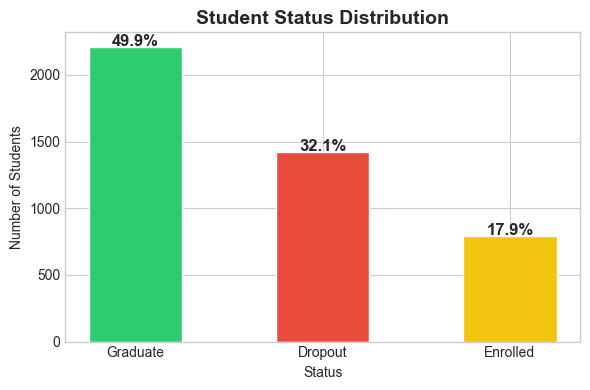

In [498]:
status_count = df['Status'].value_counts()
status_pct   = df['Status'].value_counts(normalize=True) * 100

print('Student Status Distribution')
print(pd.DataFrame({
    'Count': status_count,
    'Percentage (%)': status_pct.round(2)
}))

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(status_count.index, status_count.values,
              color=['#2ecc71', '#e74c3c', '#f1c40f'],  # dropout, enrolled, graduate
              edgecolor='white', width=0.5)

for bar, pct in zip(bars, status_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{pct:.1f}%',
            ha='center',
            fontweight='bold',
            fontsize=12)

ax.set_title('Student Status Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Students')
ax.set_xlabel('Status')

plt.tight_layout()
plt.savefig('charts/status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

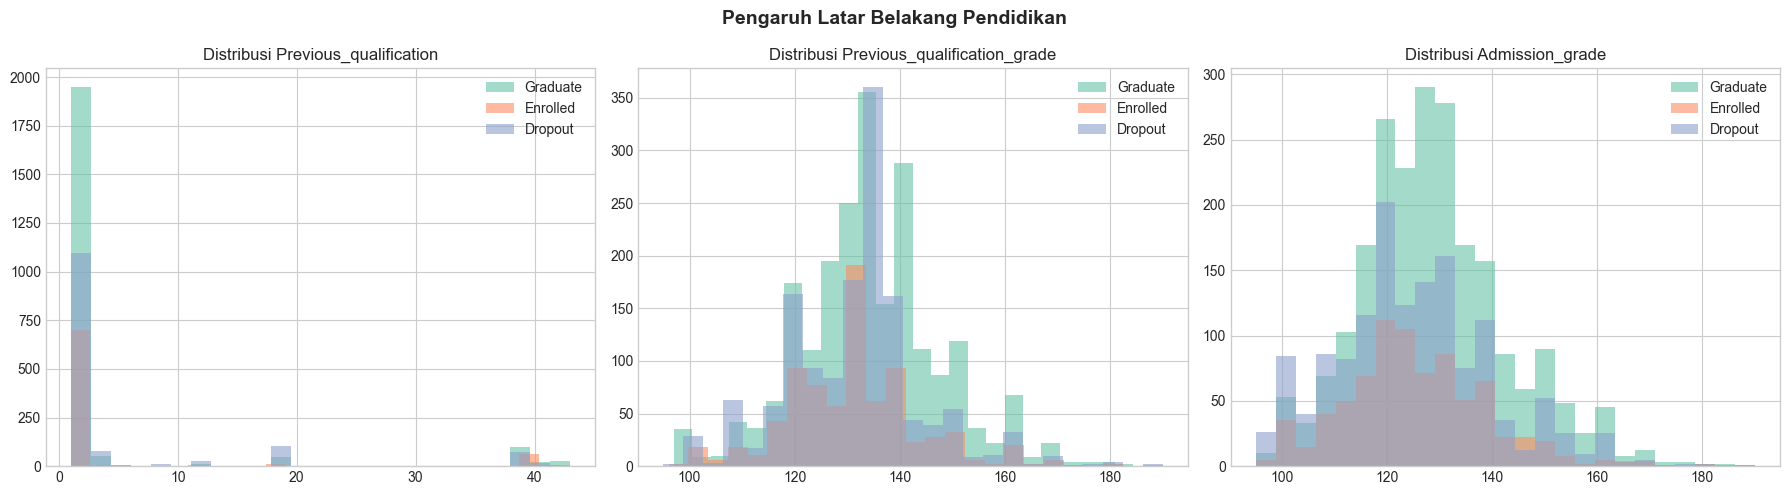

In [499]:
df['Status'] = df['Status'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})


edu_cols = [
    'Previous_qualification',
    'Previous_qualification_grade',
    'Admission_grade'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(edu_cols):
    if df[col].nunique() > 10:
        df[df['Status']==2][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Graduate')
        df[df['Status']==1][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Enrolled')
        df[df['Status']==0][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Dropout')
        axes[i].set_title(f'Distribusi {col}')
    else:
        cross = df.groupby(col)['Status'].mean()*100
        cross.sort_values(ascending=False).plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Dropout Rate by {col}')
    
    axes[i].legend()

plt.suptitle('Pengaruh Latar Belakang Pendidikan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/educational_background.png', dpi=150, bbox_inches='tight')
plt.show()

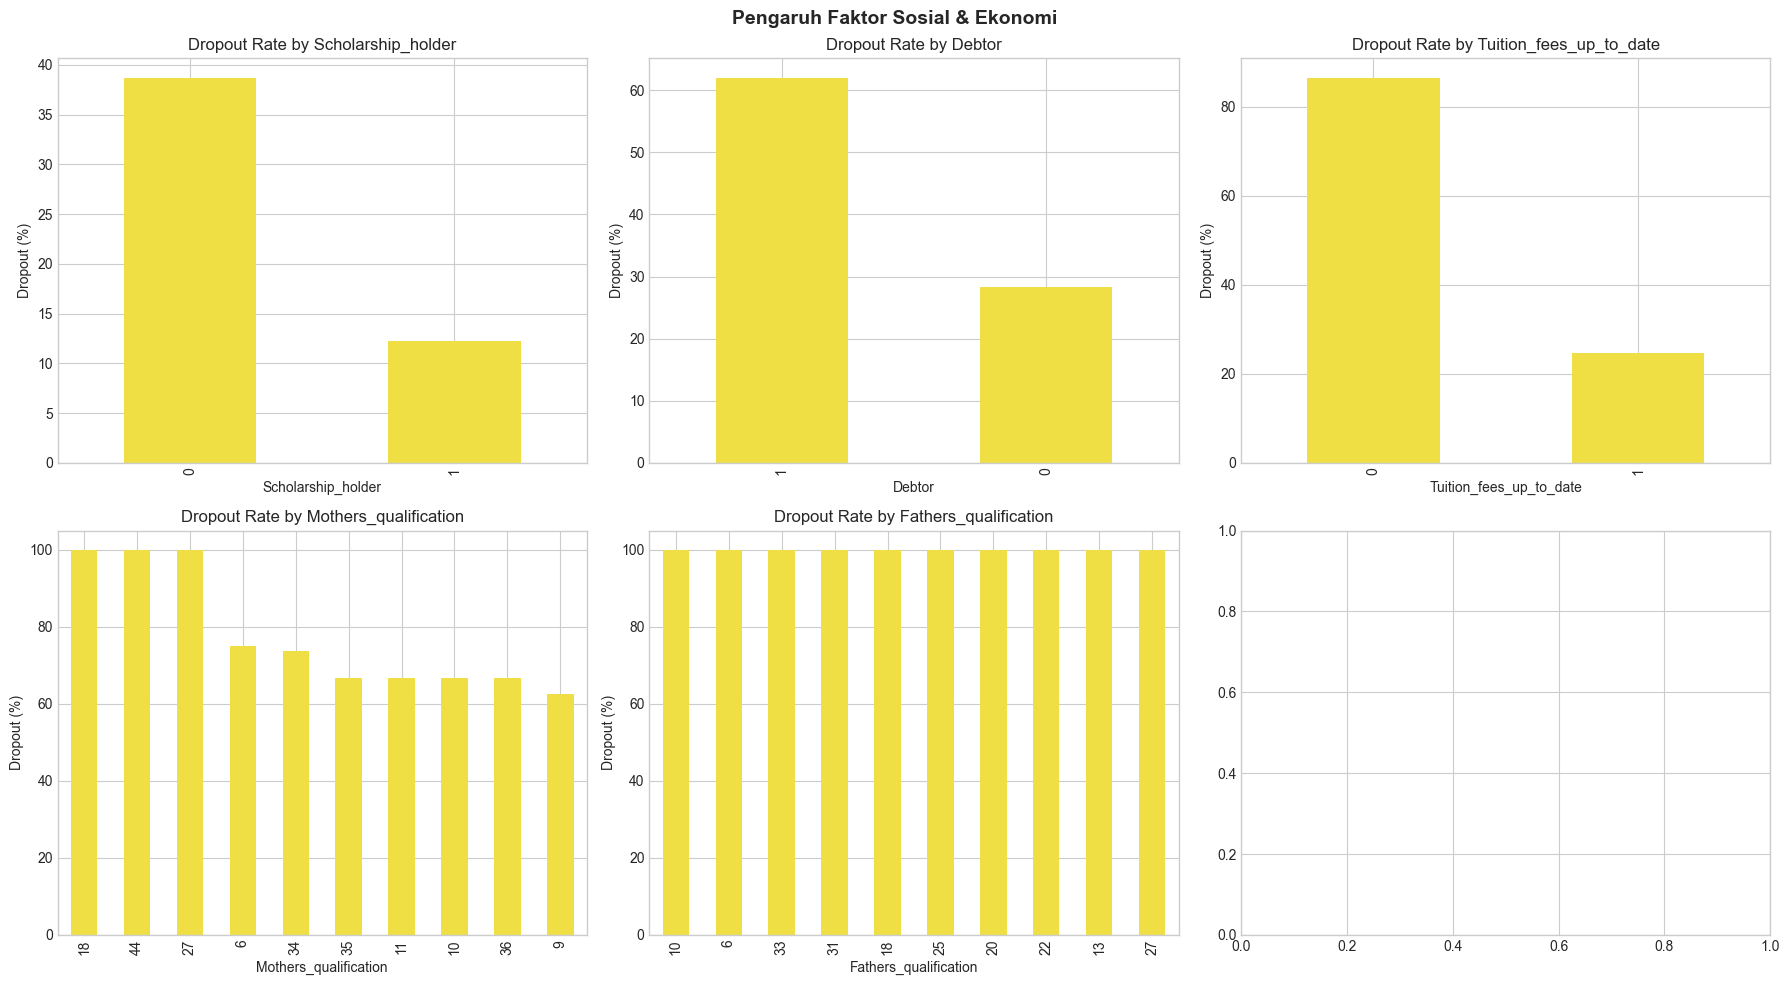

In [500]:
soc_cols = [
    'Scholarship_holder',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Mothers_qualification',
    'Fathers_qualification'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(soc_cols):
    total_per_group = df.groupby(col).size()
    dropout_per_group = df[df['Status'] == 0].groupby(col).size()
    cross = (dropout_per_group / total_per_group * 100).fillna(0)
    cross = cross.sort_values(ascending=False)
    
    if len(cross) > 10:
        cross = cross.head(10)
    
    cross.plot(kind='bar', ax=axes[i], color="#efde44")
    axes[i].set_title(f'Dropout Rate by {col}')
    axes[i].set_ylabel('Dropout (%)')

plt.suptitle('Pengaruh Faktor Sosial & Ekonomi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/social_economic_factors.png', dpi=150, bbox_inches='tight')
plt.show()

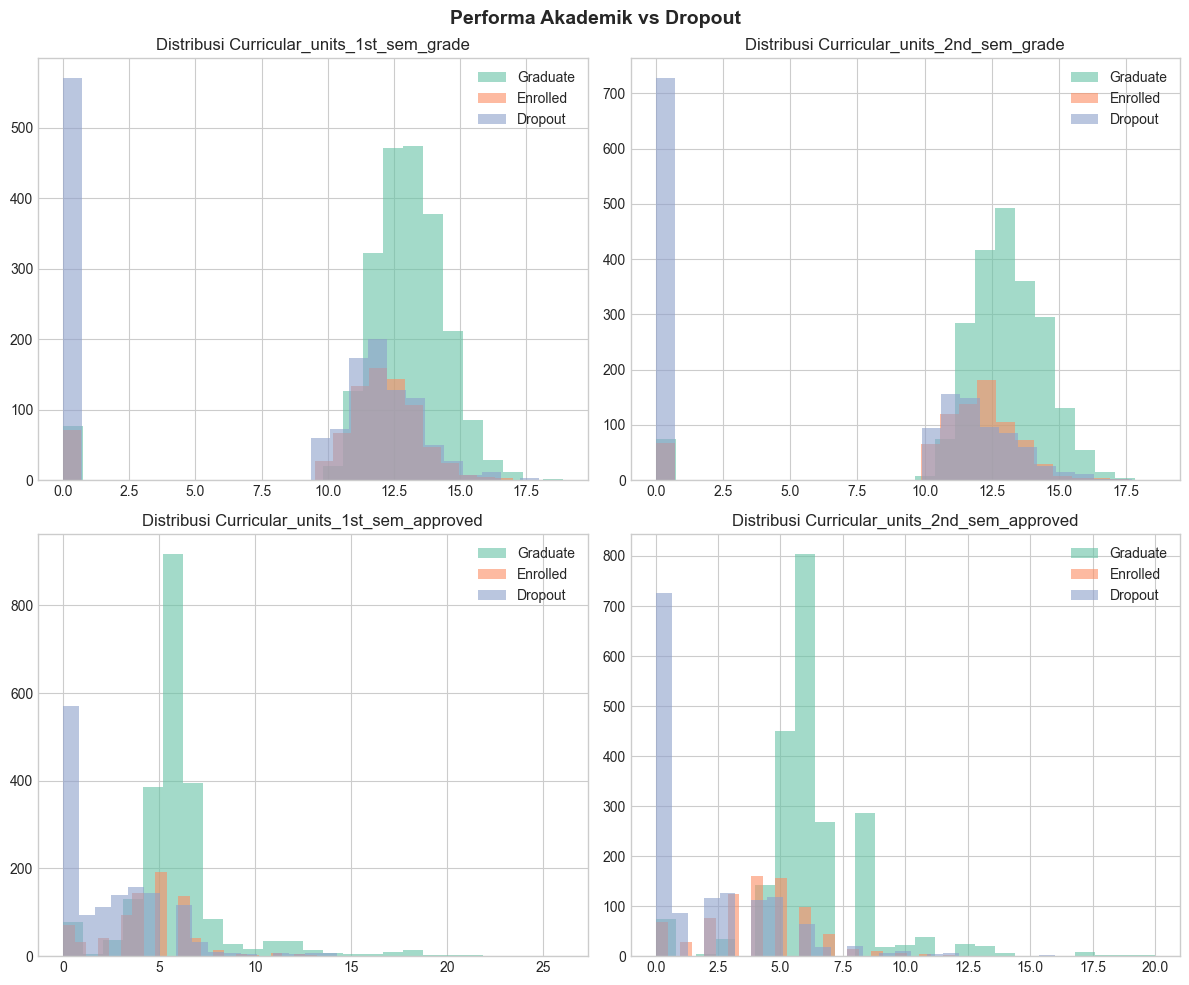

In [501]:
acad_cols = [
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(acad_cols):
    df[df['Status']==2][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Graduate')
    df[df['Status']==1][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Enrolled')
    df[df['Status']==0][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Dropout')
    
    axes[i].set_title(f'Distribusi {col}')
    axes[i].legend()

plt.suptitle('Performa Akademik vs Dropout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/academic_performance.png', dpi=150, bbox_inches='tight')
plt.show()

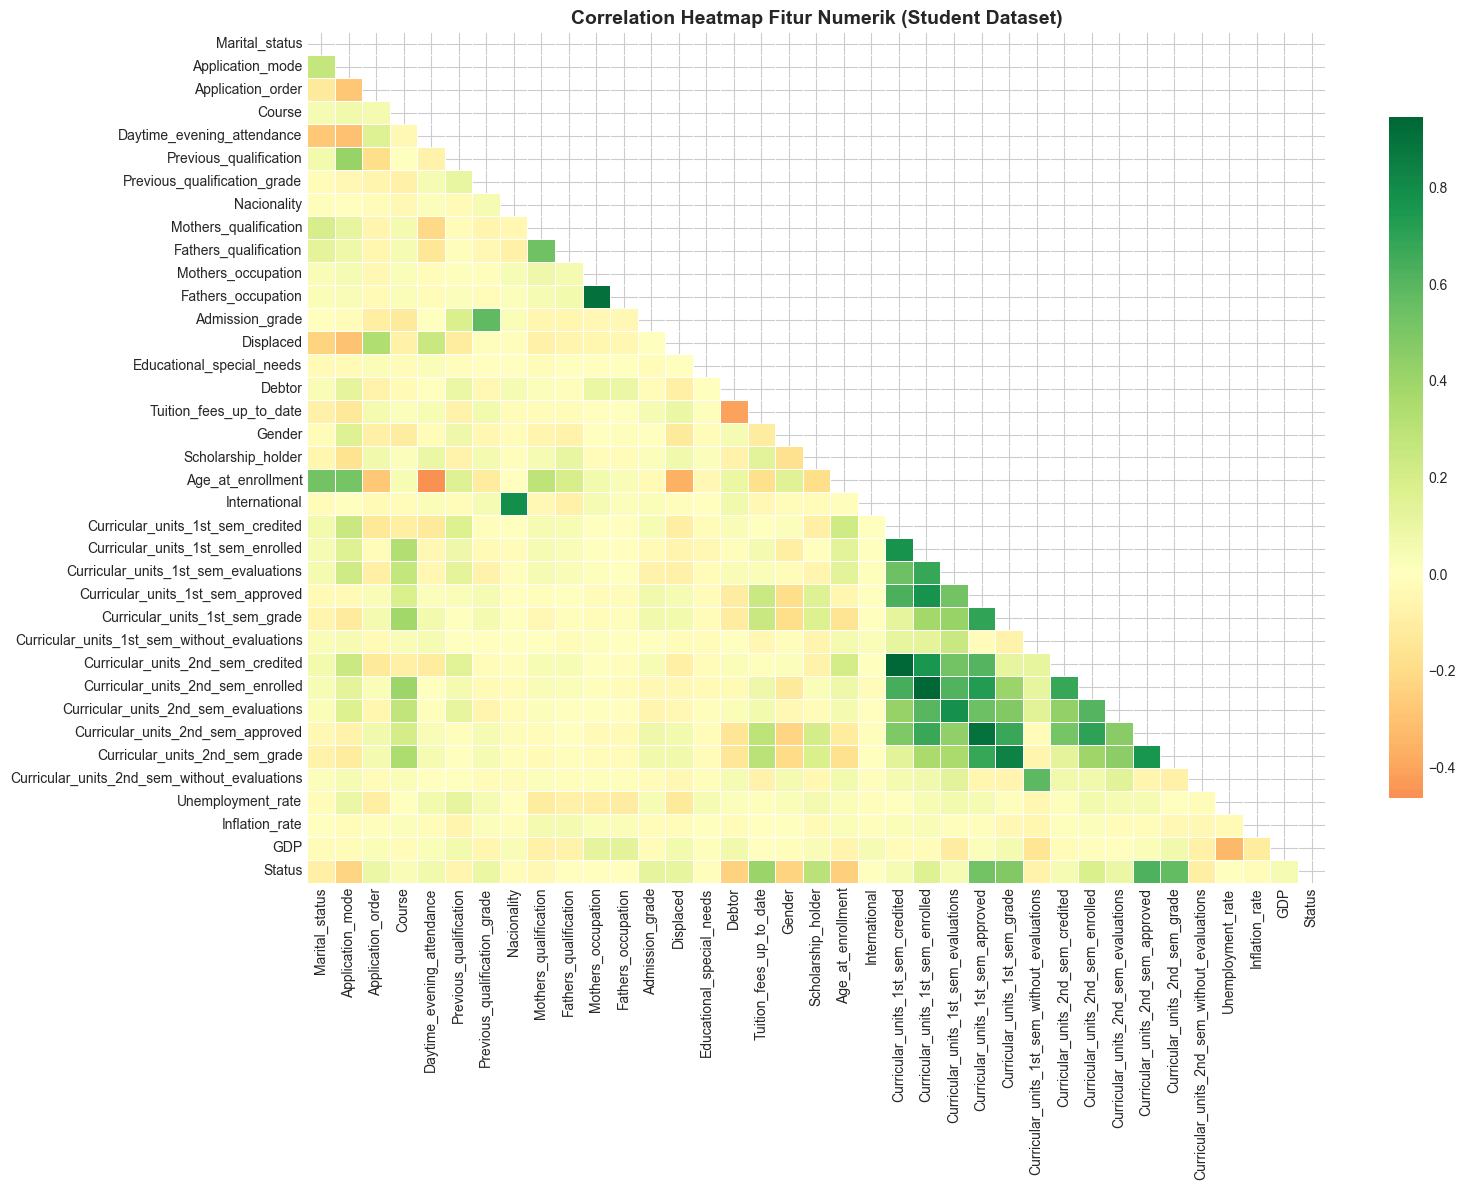

In [502]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap Fitur Numerik (Student Dataset)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/student_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Data Preparation / Preprocessing

In [503]:
df_clean = df.copy()

cols_to_drop = ['Unemployment_rate', 'Inflation_rate', 'GDP']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"Kolom dihapus (ekonomi makro): {cols_to_drop}")

Kolom dihapus (ekonomi makro): ['Unemployment_rate', 'Inflation_rate', 'GDP']



Distribusi kolom low-variance:

  [Educational_special_needs]
Educational_special_needs
0    98.847197
1     1.152803

  [Displaced]
Displaced
1    54.837251
0    45.162749


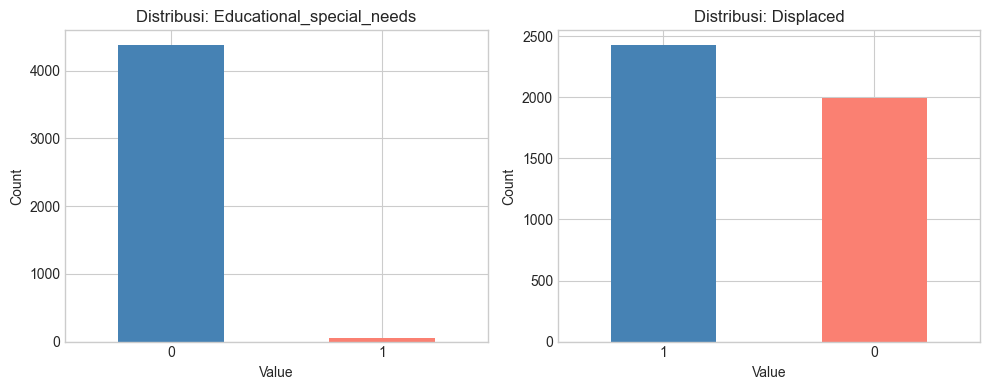

'Educational_special_needs' di-drop (dominan 98.8%)
'Displaced' dipertahankan (top freq 54.8%)


In [504]:
low_var_cols = ['Educational_special_needs', 'Displaced']
low_var_cols = [c for c in low_var_cols if c in df_clean.columns]
print("\nDistribusi kolom low-variance:")
for col in low_var_cols:
    counts = df_clean[col].value_counts(normalize=True) * 100
    print(f"\n  [{col}]")
    print(counts.to_string())

fig, axes = plt.subplots(1, len(low_var_cols), figsize=(10, 4))
if len(low_var_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, low_var_cols):
    df_clean[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(f'Distribusi: {col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

dropped_lowvar = []
for col in low_var_cols:
    top_freq = df_clean[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        df_clean.drop(columns=[col], inplace=True)
        dropped_lowvar.append(col)
        print(f"'{col}' di-drop (dominan {top_freq:.1%})")
    else:
        print(f"'{col}' dipertahankan (top freq {top_freq:.1%})")



 Korelasi 'International' vs 'Nacionality': 0.7909


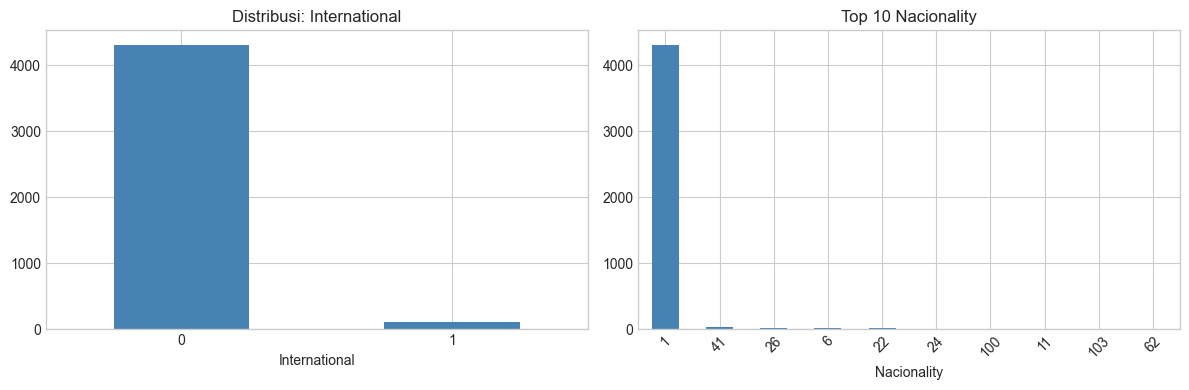

  Unique nationalities : 21
  % Portuguese (kode 1): 97.5%
'Nacionality' di-drop (redundan / terlalu sparse)


In [505]:
corr_cols = ['International', 'Nacionality']
corr_cols = [c for c in corr_cols if c in df_clean.columns]

if len(corr_cols) == 2:
    corr_val = df_clean[corr_cols].corr().iloc[0, 1]
    print(f"\n Korelasi 'International' vs 'Nacionality': {corr_val:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_clean['International'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Distribusi: International')
    axes[0].tick_params(axis='x', rotation=0)

    top_nat = df_clean['Nacionality'].value_counts().head(10)
    top_nat.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Top 10 Nacionality')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    n_unique_nat = df_clean['Nacionality'].nunique()
    pct_portuguese = (df_clean['Nacionality'] == 1).mean()
    print(f"  Unique nationalities : {n_unique_nat}")
    print(f"  % Portuguese (kode 1): {pct_portuguese:.1%}")

    if abs(corr_val) > 0.6 or pct_portuguese > 0.85:
        df_clean.drop(columns=['Nacionality'], inplace=True)
        print("'Nacionality' di-drop (redundan / terlalu sparse)")
    else:
        print("Kedua kolom dipertahankan (korelasi rendah)")


 Feature Importance (Top 20):
                             Feature  Importance
   Curricular_units_2nd_sem_approved    0.149343
   Curricular_units_1st_sem_approved    0.102240
      Curricular_units_2nd_sem_grade    0.091276
      Curricular_units_1st_sem_grade    0.066556
                     Admission_grade    0.049105
             Tuition_fees_up_to_date    0.045510
        Previous_qualification_grade    0.043046
Curricular_units_2nd_sem_evaluations    0.042898
Curricular_units_1st_sem_evaluations    0.040357
                   Age_at_enrollment    0.040242
                              Course    0.037480
                  Fathers_occupation    0.032702
                  Mothers_occupation    0.029746
                    Application_mode    0.025150
               Fathers_qualification    0.024875
               Mothers_qualification    0.024638
   Curricular_units_2nd_sem_enrolled    0.023774
   Curricular_units_1st_sem_enrolled    0.020208
                  Scholarship_holder  

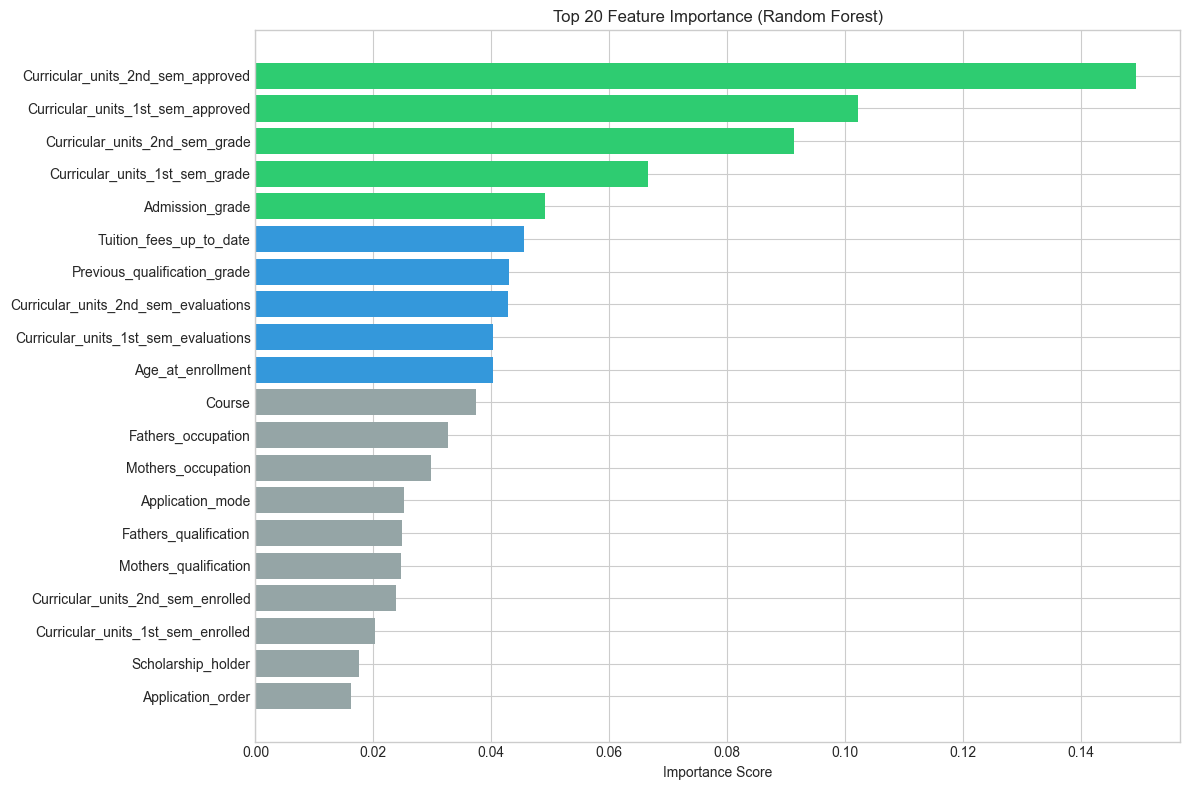


Fitur importance < 0.005 di-drop: ['Marital_status', 'Daytime_evening_attendance', 'International']


In [506]:
df_rf = df_clean.copy()

X = df_rf.drop(columns=['Status'])
y = df_rf['Status']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n Feature Importance (Top 20):")
print(importance_df.head(20).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = importance_df.head(20)
colors = ['#2ecc71' if i < 5 else '#3498db' if i < 10 else '#95a5a6'
          for i in range(len(top_n))]
bars = plt.barh(top_n['Feature'][::-1], top_n['Importance'][::-1], color=colors[::-1])
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

low_importance = importance_df[importance_df['Importance'] < 0.005]['Feature'].tolist()
if low_importance:
    df_clean.drop(columns=[c for c in low_importance if c in df_clean.columns], inplace=True)
    print(f"\nFitur importance < 0.005 di-drop: {low_importance}")
else:
    print("\nTidak ada fitur dengan importance sangat rendah.")

In [507]:
print("\n" + "="*50)
print("  RINGKASAN DATA PREPARATION")
print("="*50)
print(f"Shape awal  : {df.shape}")
print(f"Shape akhir : {df_clean.shape}")
print(f"Kolom tersisa ({df_clean.shape[1]}):")
for col in df_clean.columns:
    print(f"  - {col}")


  RINGKASAN DATA PREPARATION
Shape awal  : (4424, 37)
Shape akhir : (4424, 29)
Kolom tersisa (29):
  - Application_mode
  - Application_order
  - Course
  - Previous_qualification
  - Previous_qualification_grade
  - Mothers_qualification
  - Fathers_qualification
  - Mothers_occupation
  - Fathers_occupation
  - Admission_grade
  - Displaced
  - Debtor
  - Tuition_fees_up_to_date
  - Gender
  - Scholarship_holder
  - Age_at_enrollment
  - Curricular_units_1st_sem_credited
  - Curricular_units_1st_sem_enrolled
  - Curricular_units_1st_sem_evaluations
  - Curricular_units_1st_sem_approved
  - Curricular_units_1st_sem_grade
  - Curricular_units_1st_sem_without_evaluations
  - Curricular_units_2nd_sem_credited
  - Curricular_units_2nd_sem_enrolled
  - Curricular_units_2nd_sem_evaluations
  - Curricular_units_2nd_sem_approved
  - Curricular_units_2nd_sem_grade
  - Curricular_units_2nd_sem_without_evaluations
  - Status


In [508]:
df_clean = df_clean[df_clean['Status'] != 1].reset_index(drop=True)
df_clean['Status'] = df_clean['Status'].replace(2, 1)
X = df_clean.drop(columns=['Status'])
y = df_clean['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Class dist (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train size : (2904, 28)
Test size  : (726, 28)
Class dist (train) — 0: 1137, 1: 1767


## Modeling

In [509]:
models = {
    'Random Forest': (RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ), False),
    'XGBoost': (XGBClassifier(
        n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0
    ), False),
    'Logistic Regression': (LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ), True),
    'SVM': (SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    ), True),
}

label_names   = ['Dropout', 'Graduate']
results       = {}
trained_models = {}

for name, (model, use_scale) in models.items():
    print(f"\n{'='*55}")
    print(f"  Model Training: {name}")
    print(f"{'='*55}")

    X_tr = X_train_scaled if use_scale else X_train
    X_te = X_test_scaled  if use_scale else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)
    y_prob_positive = y_proba[:, 1]

    results[name] = {
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'y_prob'   : y_prob_positive,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'roc_auc'  : roc_auc_score(y_test, y_prob_positive),
    }
    trained_models[name] = model
    print(f"  Done — Accuracy: {results[name]['accuracy']:.4f}")

print("\n Semua model selesai dilatih.")



  Model Training: Random Forest
  Done — Accuracy: 0.9105

  Model Training: XGBoost
  Done — Accuracy: 0.9050

  Model Training: Logistic Regression
  Done — Accuracy: 0.9036

  Model Training: SVM
  Done — Accuracy: 0.9077

 Semua model selesai dilatih.


## Evaluation

In [510]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(v['accuracy'], 4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'], 4),
        'F1-Score' : round(v['f1'], 4),
        'ROC-AUC'  : round(v['roc_auc'], 4)
    }
    for name, v in results.items()
}).T

print('=== PERBANDINGAN PERFORMA MODEL ===')
print(metrics_df.to_string())
print(f'\nBest model (ROC-AUC)  : {metrics_df["ROC-AUC"].idxmax()}')
print(f'Best model (F1-Score) : {metrics_df["F1-Score"].idxmax()}')

=== PERBANDINGAN PERFORMA MODEL ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9105     0.9139  0.9105    0.9090   0.9542
XGBoost                0.9050     0.9060  0.9050    0.9039   0.9455
Logistic Regression    0.9036     0.9033  0.9036    0.9033   0.9493
SVM                    0.9077     0.9078  0.9077    0.9071   0.9516

Best model (ROC-AUC)  : Random Forest
Best model (F1-Score) : Random Forest


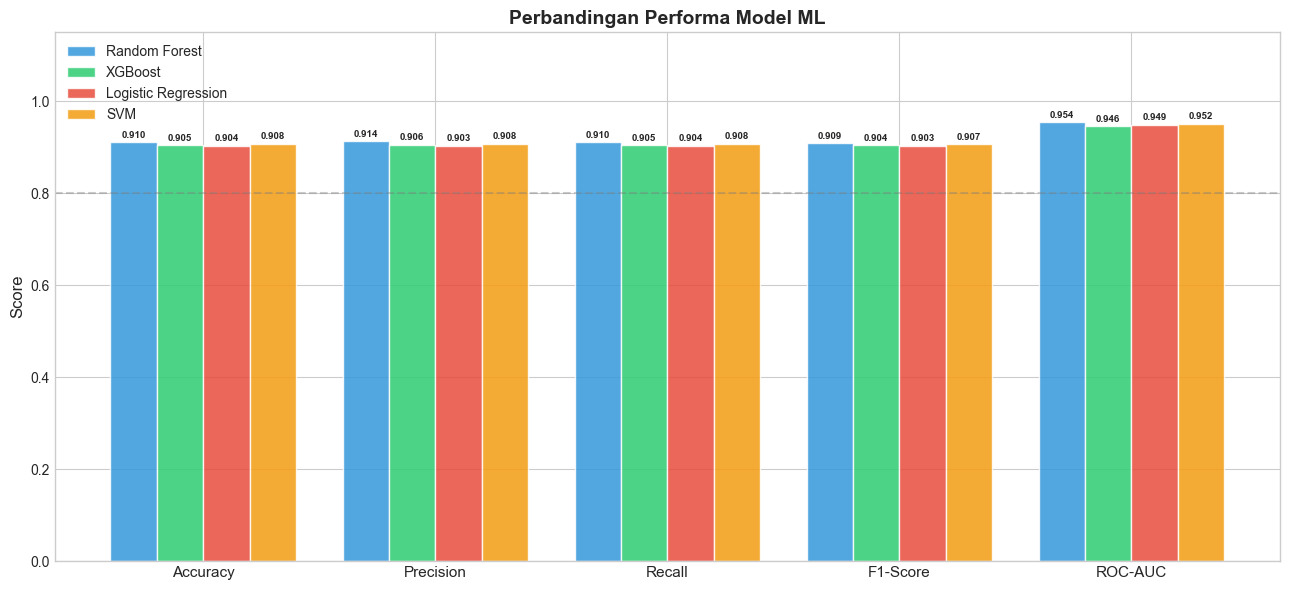

In [511]:
metrics_plot = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
x     = np.arange(len(metrics_plot.columns))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, row) in enumerate(metrics_plot.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model_name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot.columns, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa Model ML', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


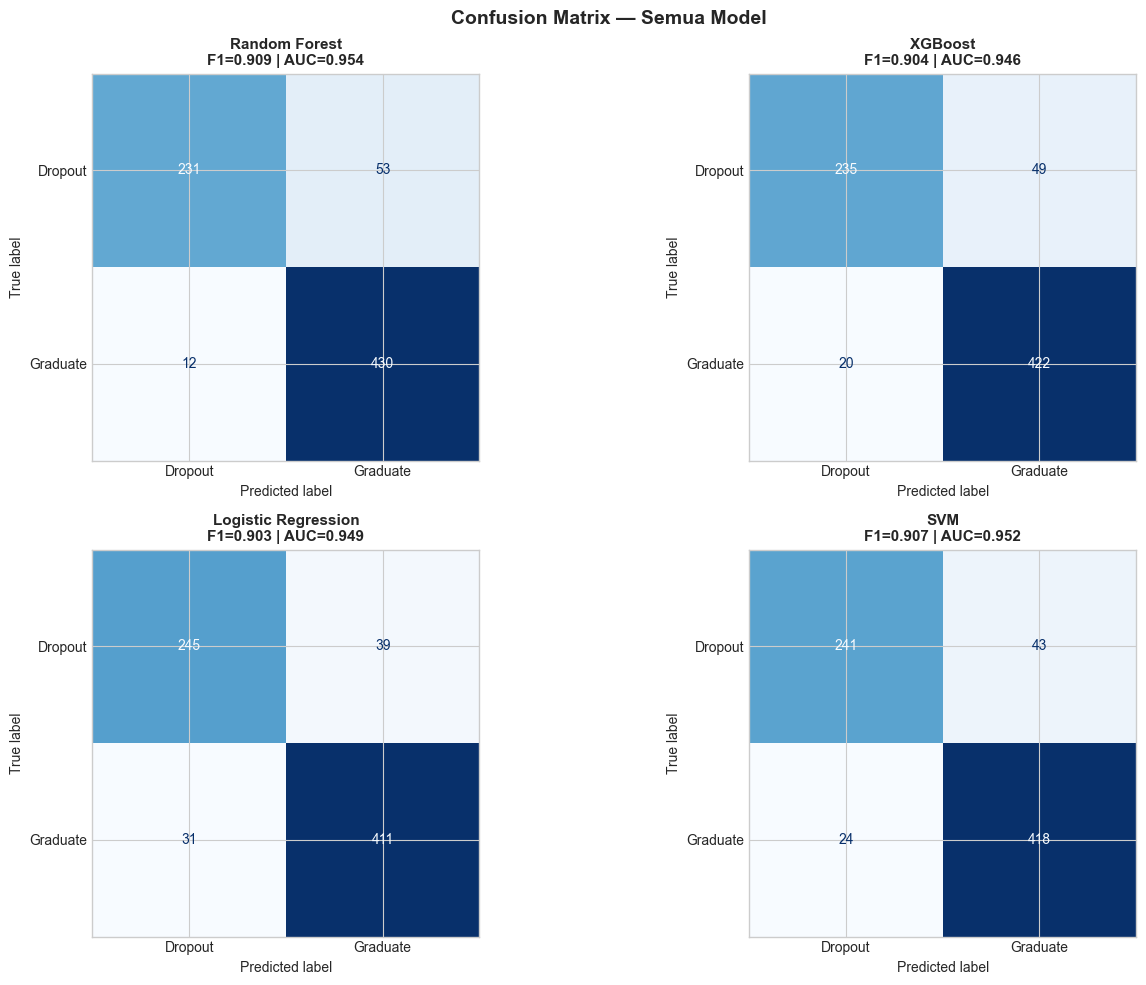

In [512]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nF1={res["f1"]:.3f} | AUC={res["roc_auc"]:.3f}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


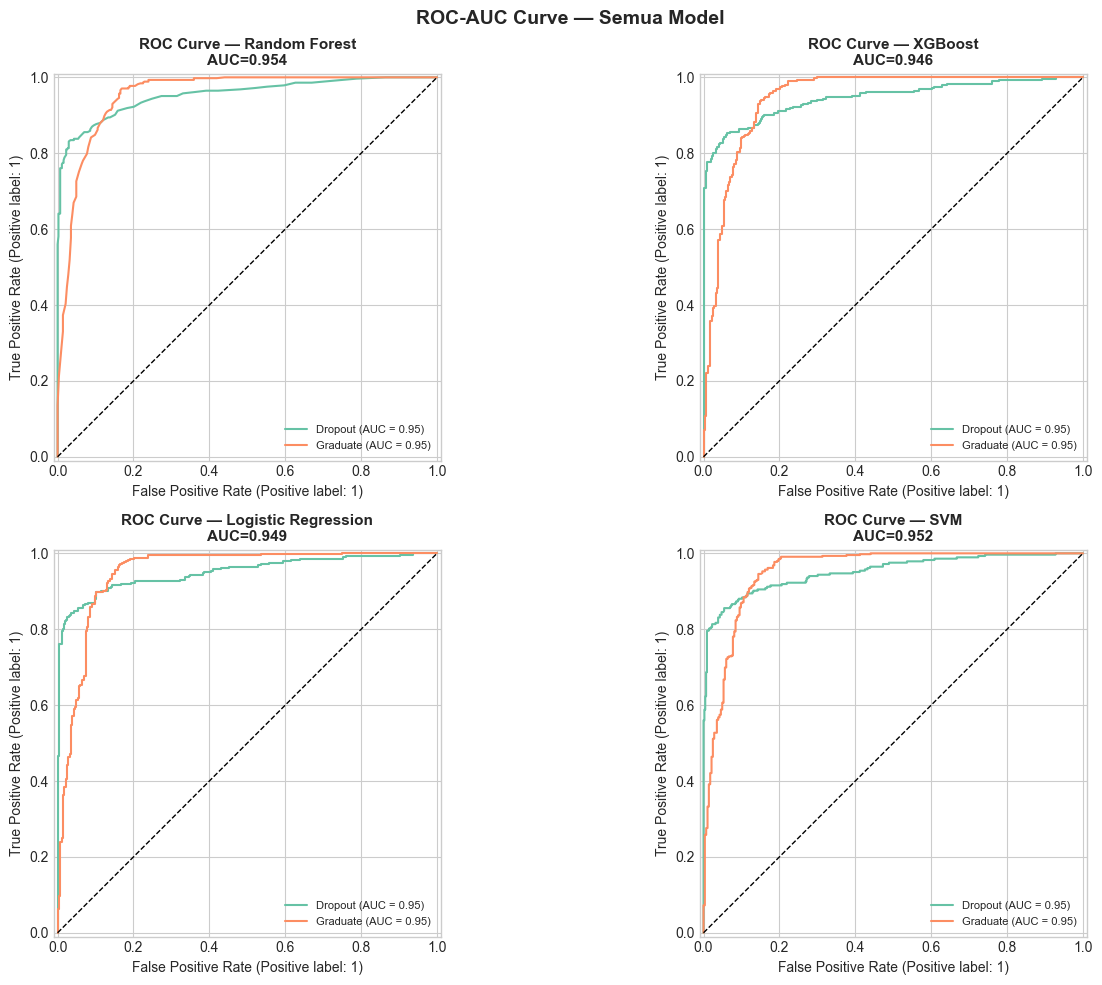

In [513]:


y_test_bin   = label_binarize(y_test, classes=[0, 1, 2])
colors_roc   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
class_labels = ['Dropout', 'Graduate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res), color in zip(axes, results.items(), colors_roc):
    for i, cls in enumerate(class_labels):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i], res['y_proba'][:, i],
            name=cls, ax=ax
        )
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC Curve — {name}\nAUC={res["roc_auc"]:.3f}',
                 fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('ROC-AUC Curve — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


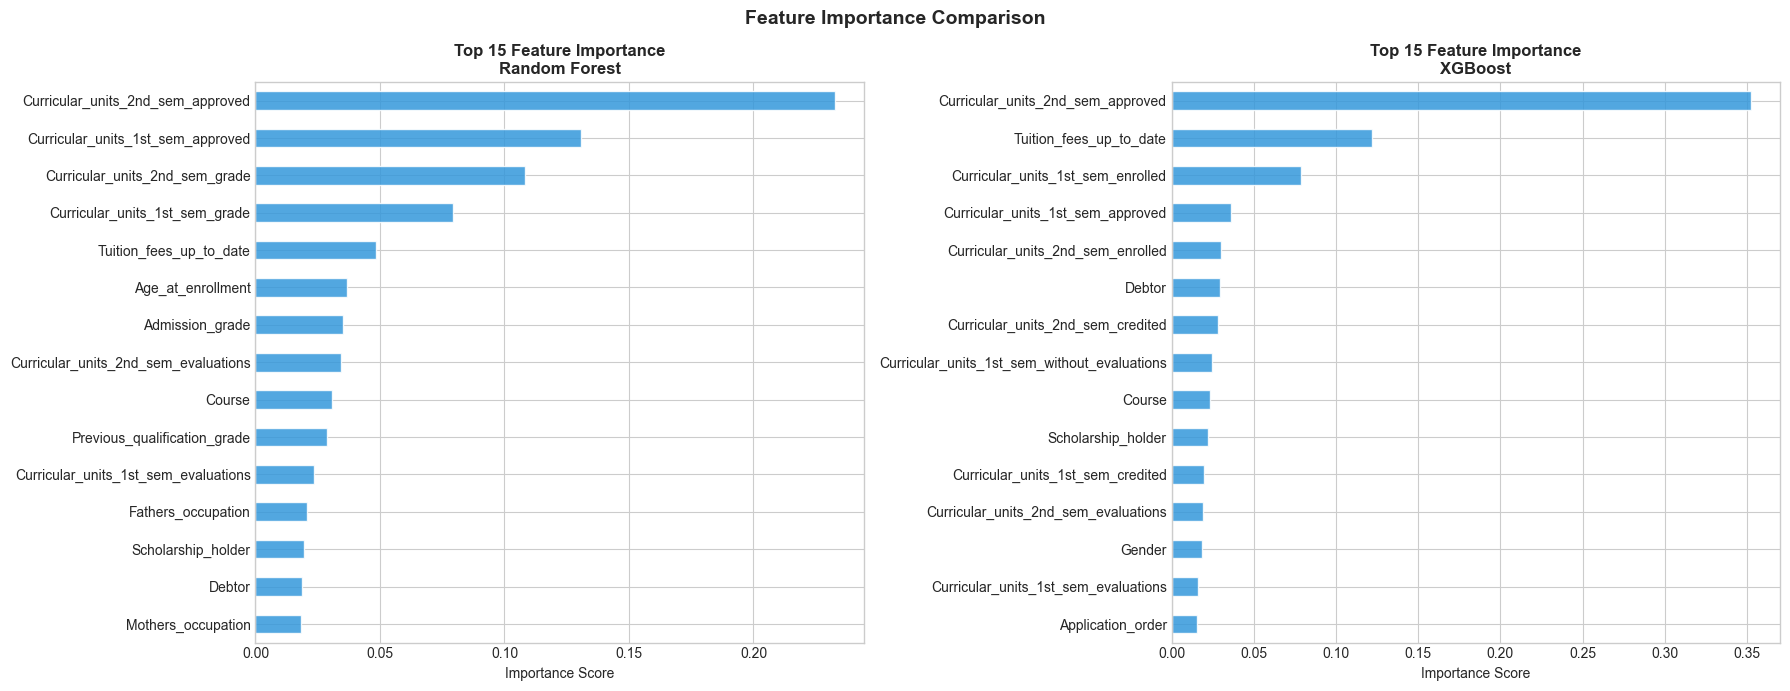

In [514]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    importance = pd.Series(
        trained_models[model_name].feature_importances_,
        index=X.columns
    )
    importance.sort_values(ascending=False).head(15).plot(
        kind='barh', ax=ax, color='#3498db', edgecolor='white', alpha=0.85
    )
    ax.set_title(f'Top 15 Feature Importance\n{model_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [515]:
best_model_name = metrics_df['ROC-AUC'].idxmax()
best_result     = results[best_model_name]

print(f'=== CLASSIFICATION REPORT: {best_model_name.upper()} (BEST MODEL) ===')
print(classification_report(y_test, best_result['y_pred'],
                            target_names=label_names))


=== CLASSIFICATION REPORT: RANDOM FOREST (BEST MODEL) ===
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.88       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



In [516]:
os.makedirs('models', exist_ok=True)

best_model = trained_models[best_model_name]
joblib.dump(best_model,         'models/best_model.pkl')
joblib.dump(scaler,             'models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

for name, model in trained_models.items():
    safe = name.lower().replace(' ', '_')
    joblib.dump(model, f'models/{safe}.pkl')

print(f'Best model : {best_model_name} -> models/best_model.pkl')
print(f'Scaler     : models/scaler.pkl')
print(f'Features   : models/feature_names.pkl')
for name in trained_models:
    safe = name.lower().replace(' ', '_')
    print(f' Model {name:<22} -> models/{safe}.pkl')


Best model : Random Forest -> models/best_model.pkl
Scaler     : models/scaler.pkl
Features   : models/feature_names.pkl
 Model Random Forest          -> models/random_forest.pkl
 Model XGBoost                -> models/xgboost.pkl
 Model Logistic Regression    -> models/logistic_regression.pkl
 Model SVM                    -> models/svm.pkl


In [517]:
import sqlite3
os.makedirs('dataset', exist_ok=True)

df_clean.to_csv('dataset/clean_data.csv', index=False)
print("clean_data.csv berhasil diekspor ke folder dataset/")

df_rf.to_csv('dataset/df_rf.csv', index=False)
print("df_rf.csv berhasil diekspor ke folder dataset/")

conn = sqlite3.connect('dataset/students.db')
df.to_sql('students', conn, if_exists='replace', index=False)
conn.close()
print("Data berhasil disimpan ke dataset/students.db")

clean_data.csv berhasil diekspor ke folder dataset/
df_rf.csv berhasil diekspor ke folder dataset/
Data berhasil disimpan ke dataset/students.db
